In [31]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch

from dataset.dataset import Dataset


In [32]:
dataset = Dataset("../data/", "G", 64)

### Male\Female distribution

In [33]:
stats = dataset.train_ds.frame['sex'].value_counts()
all = stats[0] + stats[1]
print(f"Male: {stats[0]}, Female: {stats[1]}, All: {all}")
print(f"Male: {stats[0]/all * 100:.2f}%, Female: {stats[1]/all * 100:.2f}%")

Male: 6185, Female: 5789, All: 11974
Male: 51.65%, Female: 48.35%


### MI/Healthy distribution

In [34]:
stats = dataset.train_ds.frame['has_mi'].value_counts()
all = stats[False] + stats[True]
print(f"Healthy: {stats[False]}, MI: {stats[True]}, All: {all}")
print(f"Healthy: {stats[False]/all * 100:.2f}%, MI: {stats[True]/all * 100:.2f}%")

Healthy: 7595, MI: 4379, All: 11974
Healthy: 63.43%, MI: 36.57%


### MI/Healthy and Male/Female matrix

In [35]:
dataset.train_ds.frame[['has_mi', 'sex']].value_counts()

has_mi  sex
False   1      4210
        0      3385
True    0      2800
        1      1579
Name: count, dtype: int64

In [36]:
stats = dataset.train_ds.frame[['has_mi', 'sex']].value_counts()

In [37]:
df = dataset.train_ds.frame[['has_mi', 'sex']].copy()
df['sex'] = df['sex'].map({0: 'Male', 1: 'Female'})
df['has_mi'] = df['has_mi'].map({False: 'NORM', True: 'MI'})

counts = df.value_counts().unstack()

total_mi   = counts.loc['MI'].sum()
total_norm = counts.loc['NORM'].sum()

print("=" * 45)
print("       TRAINING SET CLASS DISTRIBUTION")
print("=" * 45)
print(f"{'':10} {'Male':>8} {'Female':>8} {'Total':>8}")
print("-" * 45)
print(f"{'NORM':10} {counts.loc['NORM','Male']:>8} {counts.loc['NORM','Female']:>8} {int(total_norm):>8}")
print(f"{'MI':10} {counts.loc['MI','Male']:>8} {counts.loc['MI','Female']:>8} {int(total_mi):>8}")
print("-" * 45)
total_male   = counts['Male'].sum()
total_female = counts['Female'].sum()
print(f"{'Total':10} {int(total_male):>8} {int(total_female):>8} {int(total_male+total_female):>8}")
print("=" * 45)

mi_male_pct   = counts.loc['MI','Male']   / total_male   * 100
mi_female_pct = counts.loc['MI','Female'] / total_female * 100
print(f"\n  MI prevalence — Male: {mi_male_pct:.1f}%  Female: {mi_female_pct:.1f}%")
print(f"  Overall pos_weight  : {total_norm/total_mi:.2f}")

       TRAINING SET CLASS DISTRIBUTION
               Male   Female    Total
---------------------------------------------
NORM           3385     4210     7595
MI             2800     1579     4379
---------------------------------------------
Total          6185     5789    11974

  MI prevalence — Male: 45.3%  Female: 27.3%
  Overall pos_weight  : 1.73


### Now we check the same for the validation and test:

In [38]:
df = dataset.val_ds.frame[['has_mi', 'sex']].copy()
df['sex'] = df['sex'].map({0: 'Male', 1: 'Female'})
df['has_mi'] = df['has_mi'].map({False: 'NORM', True: 'MI'})

counts = df.value_counts().unstack()

total_mi   = counts.loc['MI'].sum()
total_norm = counts.loc['NORM'].sum()

print("=" * 45)
print("       VAIDATION CLASS DISTRIBUTION")
print("=" * 45)
print(f"{'':10} {'Male':>8} {'Female':>8} {'Total':>8}")
print("-" * 45)
print(f"{'NORM':10} {counts.loc['NORM','Male']:>8} {counts.loc['NORM','Female']:>8} {int(total_norm):>8}")
print(f"{'MI':10} {counts.loc['MI','Male']:>8} {counts.loc['MI','Female']:>8} {int(total_mi):>8}")
print("-" * 45)
total_male   = counts['Male'].sum()
total_female = counts['Female'].sum()
print(f"{'Total':10} {int(total_male):>8} {int(total_female):>8} {int(total_male+total_female):>8}")
print("=" * 45)

mi_male_pct   = counts.loc['MI','Male']   / total_male   * 100
mi_female_pct = counts.loc['MI','Female'] / total_female * 100
print(f"\n  MI prevalence — Male: {mi_male_pct:.1f}%  Female: {mi_female_pct:.1f}%")
print(f"  Overall pos_weight  : {total_norm/total_mi:.2f}")

       VAIDATION CLASS DISTRIBUTION
               Male   Female    Total
---------------------------------------------
NORM            485      470      955
MI              310      230      540
---------------------------------------------
Total           795      700     1495

  MI prevalence — Male: 39.0%  Female: 32.9%
  Overall pos_weight  : 1.77


In [39]:
df = dataset.test_ds.frame[['has_mi', 'sex']].copy()
df['sex'] = df['sex'].map({0: 'Male', 1: 'Female'})
df['has_mi'] = df['has_mi'].map({False: 'NORM', True: 'MI'})

counts = df.value_counts().unstack()

total_mi   = counts.loc['MI'].sum()
total_norm = counts.loc['NORM'].sum()

print("=" * 45)
print("       TESTING SET CLASS DISTRIBUTION")
print("=" * 45)
print(f"{'':10} {'Male':>8} {'Female':>8} {'Total':>8}")
print("-" * 45)
print(f"{'NORM':10} {counts.loc['NORM','Male']:>8} {counts.loc['NORM','Female']:>8} {int(total_norm):>8}")
print(f"{'MI':10} {counts.loc['MI','Male']:>8} {counts.loc['MI','Female']:>8} {int(total_mi):>8}")
print("-" * 45)
total_male   = counts['Male'].sum()
total_female = counts['Female'].sum()
print(f"{'Total':10} {int(total_male):>8} {int(total_female):>8} {int(total_male+total_female):>8}")
print("=" * 45)

mi_male_pct   = counts.loc['MI','Male']   / total_male   * 100
mi_female_pct = counts.loc['MI','Female'] / total_female * 100
print(f"\n  MI prevalence — Male: {mi_male_pct:.1f}%  Female: {mi_female_pct:.1f}%")
print(f"  Overall pos_weight  : {total_norm/total_mi:.2f}")

       TESTING SET CLASS DISTRIBUTION
               Male   Female    Total
---------------------------------------------
NORM            516      447      963
MI              297      253      550
---------------------------------------------
Total           813      700     1513

  MI prevalence — Male: 36.5%  Female: 36.1%
  Overall pos_weight  : 1.75


We see that in train MI is more common for male patients, while male\female ration is almost balanced. The test set is more balanced in terms of MI.

### Age analysis

In [43]:
df = dataset.train_ds.frame

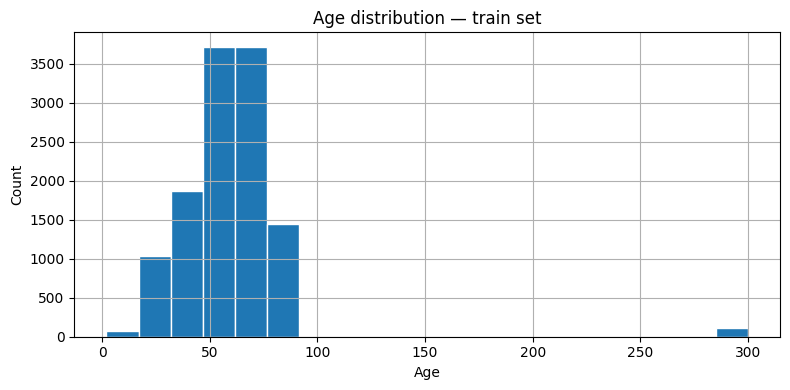

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df['age'].hist(bins=20, edgecolor='white')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age distribution — train set')
plt.tight_layout()
plt.show()

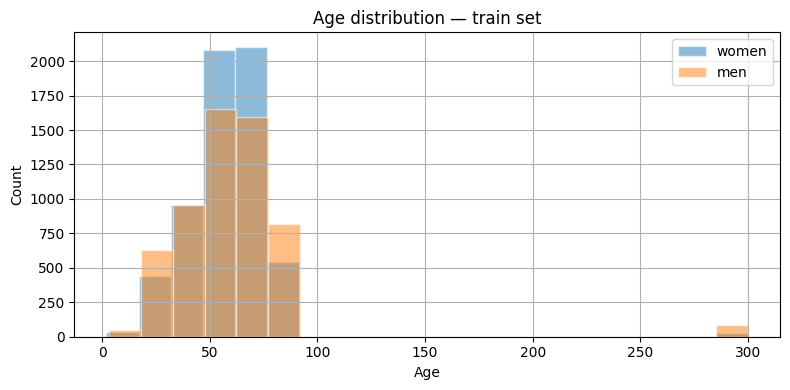

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df[df['sex']==0]['age'].hist(bins=20, edgecolor='white', alpha=0.5, label='women')
df[df['sex']==1]['age'].hist(bins=20, edgecolor='white', alpha=0.5, label='men')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age distribution — train set')
plt.tight_layout()
plt.legend()
plt.show()

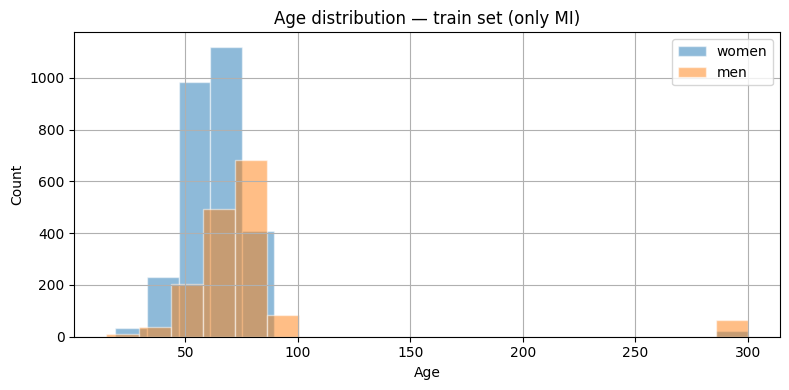

In [48]:
import matplotlib.pyplot as plt
df = df[df['has_mi']]
plt.figure(figsize=(8, 4))
df[df['sex']==0]['age'].hist(bins=20, edgecolor='white', alpha=0.5, label='women')
df[df['sex']==1]['age'].hist(bins=20, edgecolor='white', alpha=0.5, label='men')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age distribution — train set (only MI)')
plt.tight_layout()
plt.legend()
plt.show()

This corresponds to the general intuiiton about the statistic of MI.

### ECG comparison

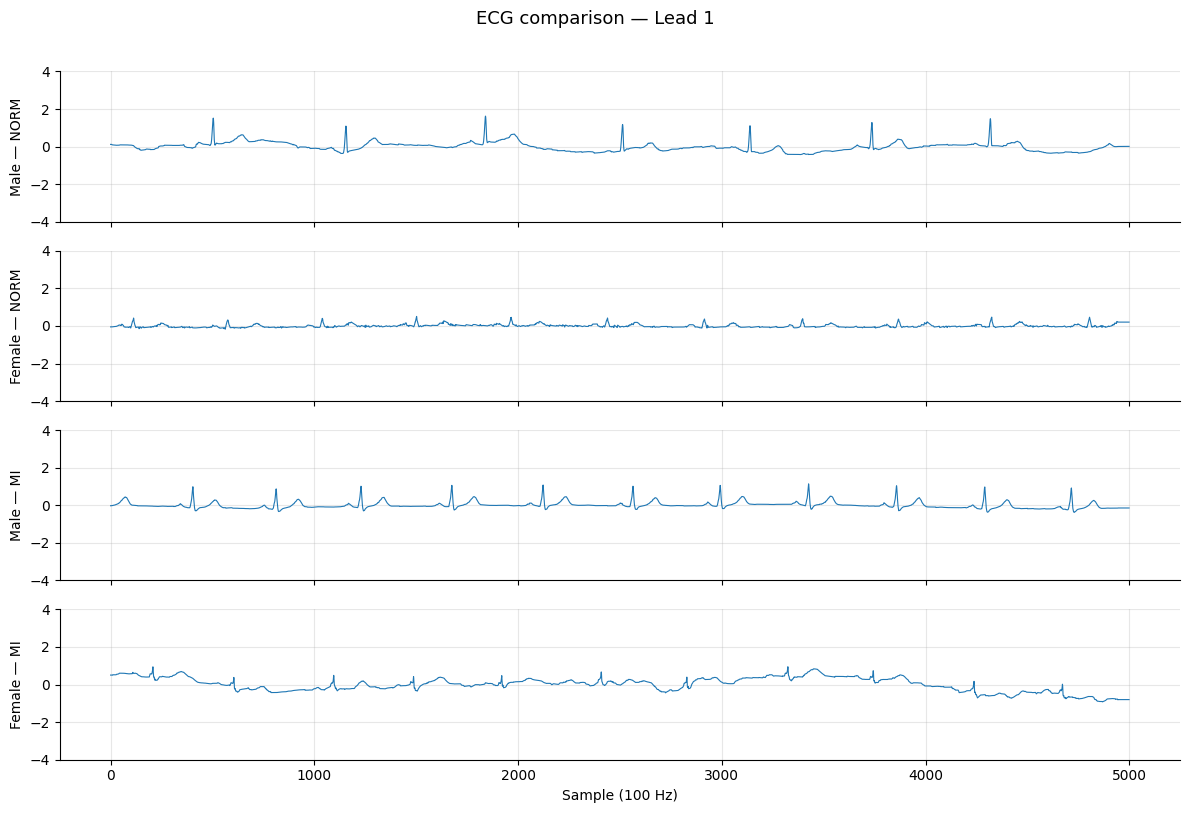

In [ ]:
import matplotlib.pyplot as plt
import wfdb
import numpy as np
from utils.metrics import plot_ecg_comparison

plot_ecg_comparison(dataset, lead=1)